# Mesh sanity checks

When designing a triangular mesh of the ocean to be used as a latent processor graph in encode-process-decode architecture, one encounters the same problems that emerge when incorporating simulation data coming from different Earth system components developed indipendently. Indeed, each simulation setting might define differently the geometry of the domain (e.g. use different approximations for the geoid, or use different definitions for the coastlines). However, even when the domain is exactly the same, the use of different discretizations introduce inconsistencies and aliasing. Fortunately, the encoder and decoder of the proposed architecture are flexible enough that such issues do not constitute a severe threat. Some care is required though. 

Firstly, notice that if the ball with prescribed radius around a mesh node does not contain at least one valid grid point, then the features of such mesh node will not be updated during the encode phase. Secondly, if a mesh node does not belong to at least one triangle which is the nearest (among those of the whole mesh) to some grid point, then its features value will not be used in message passing steps on the decode graph. However, in both previous cases, such mesh nodes will participate in message passing on the processor graph.

As the internals of deep neural networks are not fully understood, and it is unknown, a-priori, what could be the effect of including in the latent processor graph such "_disconnected_" nodes, which have no analogue in GraphCast, we chose the most conservative option: to eliminate them. Furthermore, as it is convenient to continue working with a processor graph which is also a mesh, we need to filter faces along with vertices and edges. 

Indeed, the implementation of `mask_mesh` translates the problem of filtering invalid vertices, to that of filtering invalid faces (a face is valid if one, or all, depending on the selected mode, of its vertices are valid), and then removing vertices that do not belong to any marked face.

As illustrated in this notebook. All of the removed points were close to Antarctica, due to differences in the coastlines definitions between the NaturalEarth and GLORYS12, and due to the fact that GLORYS12 mask all points below 90°S.

In [1]:
import platform
import pathlib

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import hvplot.pandas


from graphcast.ocean_mesh_utils import read_mesh
from graphcast.mesh_graph import MeshGraph, faces_to_edges, mesh_to_wgs
from graphcast.mesh_connectivity import get_connected_mesh_nodes, mask_mesh
from graphcast.plot_utils import get_line_collection
from graphcast.ocean_mesh_utils import get_transform, cartesian_proj, platecarree_proj, stereographic_proj

In [2]:
if platform.node().endswith('leonardo.local'):
    data_dir = pathlib.Path("/leonardo_scratch/large/userexternal/scampane/xcast/data")
else:
    data_dir = pathlib.Path("../data")

In [3]:
dataset = xr.open_dataset(data_dir / 'dataset/dataset_tres-1d_res-0p25_levels-10_arco', engine='zarr')
dataset = dataset.isel(time=slice(0, 8))
dataset

<xarray.Dataset> Size: 2GB
Dimensions:         (time: 7, lat: 721, lon: 1440, level: 10)
Coordinates:
    depth           (level) float32 40B ...
  * lat             (lat) float32 3kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * level           (level) int64 80B 0 4 8 12 16 20 24 28 32 34
  * lon             (lon) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time            (time) datetime64[ns] 56B 2000-01-01 ... 2000-01-07
Data variables: (12/33)
    10u             (time, lat, lon) float32 29MB ...
    10v             (time, lat, lon) float32 29MB ...
    2d              (time, lat, lon) float32 29MB ...
    2t              (time, lat, lon) float32 29MB ...
    deptho          (lat, lon) float32 4MB ...
    dis24           (time, lat, lon) float32 29MB ...
    ...              ...
    vsd             (time, lat, lon) float32 29MB ...
    vsi             (time, lat, lon) float32 29MB ...
    waverys_deptho  (lat, lon) float32 4MB ...
    waverys_mask    (lat, lon) bool 1MB ...
    z               (lat, lon) float32 4MB ...
    zos             (time, lat, lon) float32 29MB ...
Attributes:
    last_updated:           2025-07-17 01:52:23.900829+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-04-30
    valid_time_stop_era5t:  2025-07-11

In [4]:
ocean_mesh, boundary_nodes = read_mesh(data_dir / 'geometry/constant_coarse.msh')
ocean_mesh_graph = MeshGraph(vertices=ocean_mesh.vertices, edges=faces_to_edges(ocean_mesh.faces), faces=ocean_mesh.faces)
ocean_mesh_graph

MeshGraph(vertices=array([[  355363.83667211,  -646318.1715593 , -6314105.72949731],
       [-1153039.8947619 ,  -323703.54492538, -6243686.1427724 ],
       [  526422.03168573,  -975463.29659177, -6260022.06291247],
       ...,
       [-2305821.06727144,  5834003.82022015,  1148620.30770627],
       [ -492019.79432623,  6249868.85246773,  1169813.94951708],
       [ 4484607.87286297,  4060397.00654722, -2013646.65180174]],
      shape=(22454, 3)), faces=array([[ 1578,  9020,  1577],
       [ 9957, 13722, 13721],
       [ 8666, 18201,  7857],
       ...,
       [ 2779,  2728,  2729],
       [ 2779,  2729,  2778],
       [ 2768,  2766,  2767]], shape=(42303, 3)), edges=(array([1578, 9957, 8666, ..., 2729, 2778, 2767], shape=(126909,)), array([ 9020, 13722, 18201, ...,  2779,  2779,  2768], shape=(126909,))))

In [5]:
def get_max_edge_distance(mesh):
  senders, receivers = faces_to_edges(mesh.faces)
  edge_distances = np.linalg.norm(
      mesh.vertices[senders] - mesh.vertices[receivers], axis=-1)
  return edge_distances.max()

query_radius = 0.6 * get_max_edge_distance(ocean_mesh_graph)
query_radius

np.float64(130156.1208958847)

In [6]:
mask = dataset['glorys_mask'].isel(level=0, drop=True)

connected_mesh_nodes = get_connected_mesh_nodes(grid_lat=mask['lat'], 
                                                grid_lon=mask['lon'], 
                                                mesh_graph=ocean_mesh_graph, 
                                                grid_mask=mask, 
                                                query_radius=0.6 * get_max_edge_distance(ocean_mesh_graph),
                                                workers=-1)

connected_mesh_graph, _ = mask_mesh(connected_mesh_nodes, ocean_mesh_graph, mode='all')
connected_mesh_graph

MeshGraph(vertices=array([[ 5015507.80739259,  1661044.75065265, -3561008.46348005],
       [-1099709.44731802, -1437788.23625593, -6095378.4855188 ],
       [ 1026072.4959449 , -3999275.83531918, -4845140.58831076],
       ...,
       [-2305821.06727144,  5834003.82022015,  1148620.30770627],
       [ -492019.79432623,  6249868.85246773,  1169813.94951708],
       [ 4484607.87286297,  4060397.00654722, -2013646.65180174]],
      shape=(22302, 3)), faces=array([[ 1488,  8921,  1487],
       [ 9856, 13607, 13606],
       [ 8567, 18076,  7761],
       ...,
       [ 2686,  2635,  2636],
       [ 2686,  2636,  2685],
       [ 2675,  2673,  2674]], shape=(42058, 3)), edges=(array([1488, 9856, 8567, ..., 2636, 2685, 2674], shape=(126174,)), array([ 8921, 13607, 18076, ...,  2686,  2686,  2675], shape=(126174,))))

In [7]:
def get_node_set(graph):
    return set(tuple(graph.vertices[n, :].tolist()) for n in range(graph.vertices.shape[0]))

In [8]:
all_nodes = get_node_set(ocean_mesh_graph)
connected_nodes = get_node_set(connected_mesh_graph)
removed_nodes = np.stack(list(all_nodes - connected_nodes))

In [9]:
removed_nodes_coords = get_transform(cartesian_proj, platecarree_proj)(removed_nodes)[:, 0:2]
removed_nodes_df = pd.DataFrame(dict(longitude=removed_nodes_coords[:, 0], latitude=removed_nodes_coords[:, 1]))
removed_nodes_df

,longitude,latitude
0,163.851781,-82.174936
1,-63.068606,-74.887978
2,170.364804,-79.077332
3,-171.084276,-82.907325
4,-69.682126,-80.229137
...,...,...
147,174.556334,-81.923637
148,-59.620432,-77.324044
149,168.029686,-82.185059
150,-18.603628,-75.418330


In [10]:
removed_nodes_df.hvplot.points('longitude', 'latitude', geo=True, tiles=True, height=300, width=700)

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [longitude,latitude]

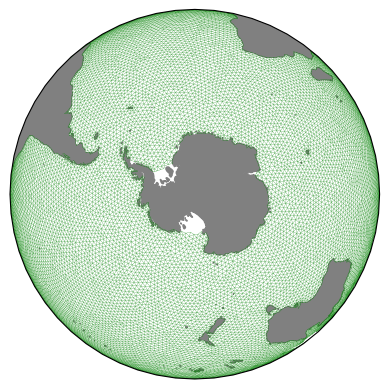

In [11]:
fig = plt.figure()

ax = fig.add_subplot(1, 1, 1, projection=ccrs.Orthographic(central_latitude=-90))

ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='grey'))

connected_mesh_wgs_graph = mesh_to_wgs(connected_mesh_graph)

latitudes, longitudes = connected_mesh_wgs_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="green", s=2.0, zorder=2, alpha=0.0, transform=ccrs.PlateCarree())

lc = get_line_collection(connected_mesh_wgs_graph, linewidths=0.16, colors="green", transform=ccrs.Geodetic())
ax.add_collection(lc)